In [19]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# 1. Load data
data = pd.read_csv('../Data/OldSensorNodeData.csv', parse_dates=['Timestamp'])

In [11]:
# 2. Extract timestamp features
data['hour'] = data['Timestamp'].dt.hour
data['minute'] = data['Timestamp'].dt.minute
data['second'] = data['Timestamp'].dt.second
# Optional: data['day_of_week'] = data['Timestamp'].dt.dayofweek

In [12]:
# 3. Define shift function
def shift_target(df, col, steps):
    return df[col].shift(-steps)

In [13]:
# 4. Prepare features and targets
feature_cols = ['AQI', 'Temp', 'Hum', 'Pres', 'hour', 'minute', 'second']
X = data[feature_cols].copy()

# Shift targets for 1, 5, 15 min ahead (5-sec intervals)
for col in ['AQI', 'Temp', 'Hum']:
    X[f'{col}_1min'] = shift_target(data, col, 12)
    X[f'{col}_5min'] = shift_target(data, col, 60)
    X[f'{col}_15min'] = shift_target(data, col, 180)

# Drop rows with NaN (end of dataset)
X.dropna(inplace=True)

# Separate features and targets
target_cols = [c for c in X.columns if '_' in c]  # all shifted columns
feature_cols_final = ['AQI', 'Temp', 'Hum', 'Pres', 'hour', 'minute', 'second']

X_final = X[feature_cols_final]
y_final = X[target_cols]


In [14]:
# 5. Chronological split
split_idx = int(len(X_final) * 0.8)
X_train, X_test = X_final[:split_idx], X_final[split_idx:]
y_train, y_test = y_final[:split_idx], y_final[split_idx:]

print('Random Forest data preprocessing done!')

Random Forest data preprocessing done!


In [16]:
# Initialize base Random Forest with all processors
rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Wrap in MultiOutputRegressor for multi-target prediction
rf_model = MultiOutputRegressor(rf_base)

# Train the model
rf_model.fit(X_train, y_train)
print('Random Forest Training Done!')

Random Forest Training Done!


In [17]:
# Predict
y_pred_rf = rf_model.predict(X_test)
print('Random Forest Prediction Done!')

Random Forest Prediction Done!


In [18]:
def evaluate_model(y_true, y_pred):
    metrics = pd.DataFrame(columns=['Target', 'MAE', 'RMSE', 'R2'])
    targets = y_true.columns
    for i, target in enumerate(targets):
        y_t = y_true[target].values
        y_hat = y_pred[:, i]
        mae = mean_absolute_error(y_t, y_hat)
        rmse = np.sqrt(mean_squared_error(y_t, y_hat))
        r2 = r2_score(y_t, y_hat)
        metrics.loc[i] = [target, mae, rmse, r2]

    # Combined metrics
    combined_mae = mean_absolute_error(y_true, y_pred, multioutput='uniform_average')
    combined_rmse = np.sqrt(mean_squared_error(y_true, y_pred, multioutput='uniform_average'))
    combined_r2 = r2_score(y_true, y_pred, multioutput='uniform_average')
    metrics.loc[len(targets)] = ['Combined', combined_mae, combined_rmse, combined_r2]

    return metrics

# Evaluate
rf_metrics = evaluate_model(y_test, y_pred_rf)
print(rf_metrics)


       Target        MAE       RMSE        R2
0    AQI_1min   2.124884   3.196354  0.548863
1    AQI_5min   9.190037  10.731142 -4.061797
2   AQI_15min  10.012365  11.354846 -4.638643
3   Temp_1min   0.240407   0.817538  0.124611
4   Temp_5min   0.452601   1.046516 -0.442738
5  Temp_15min   1.053399   1.497980 -1.794037
6    Hum_1min   0.797648   1.982406 -0.160256
7    Hum_5min   2.723115   3.564668 -2.762202
8   Hum_15min   4.873150   6.095845 -9.118211
9    Combined   3.496401   5.888881 -2.478268


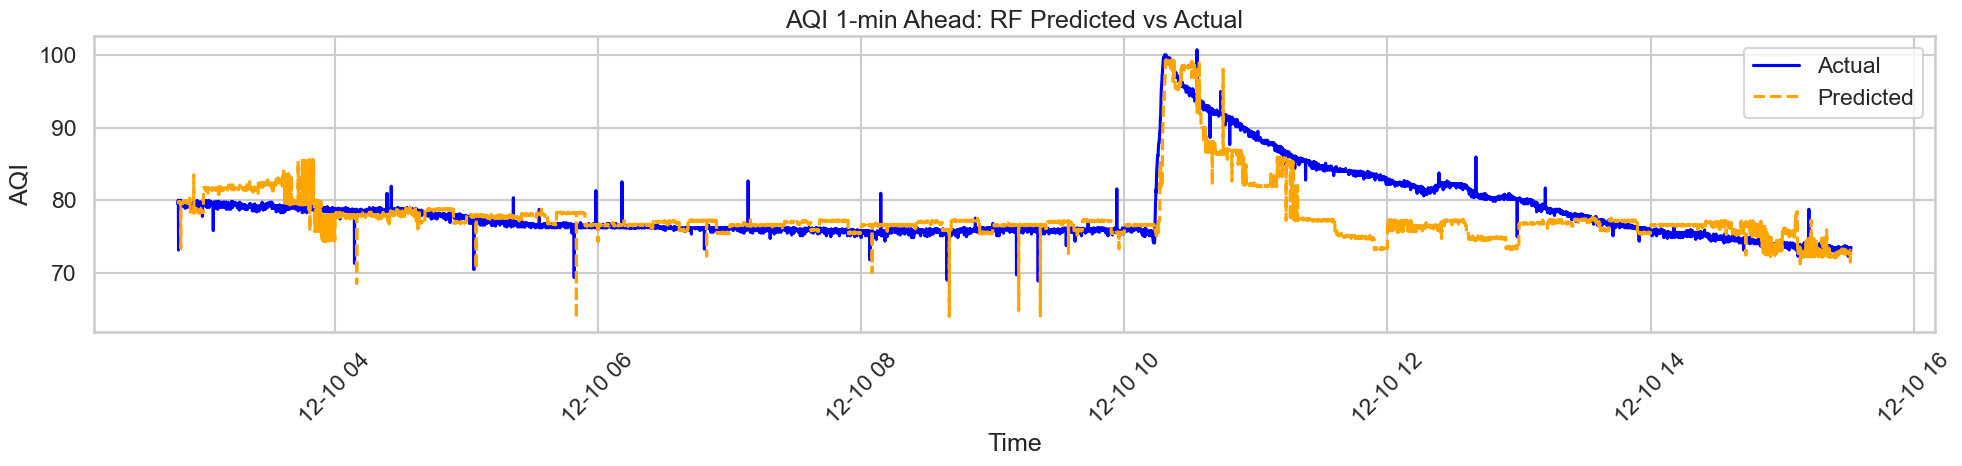

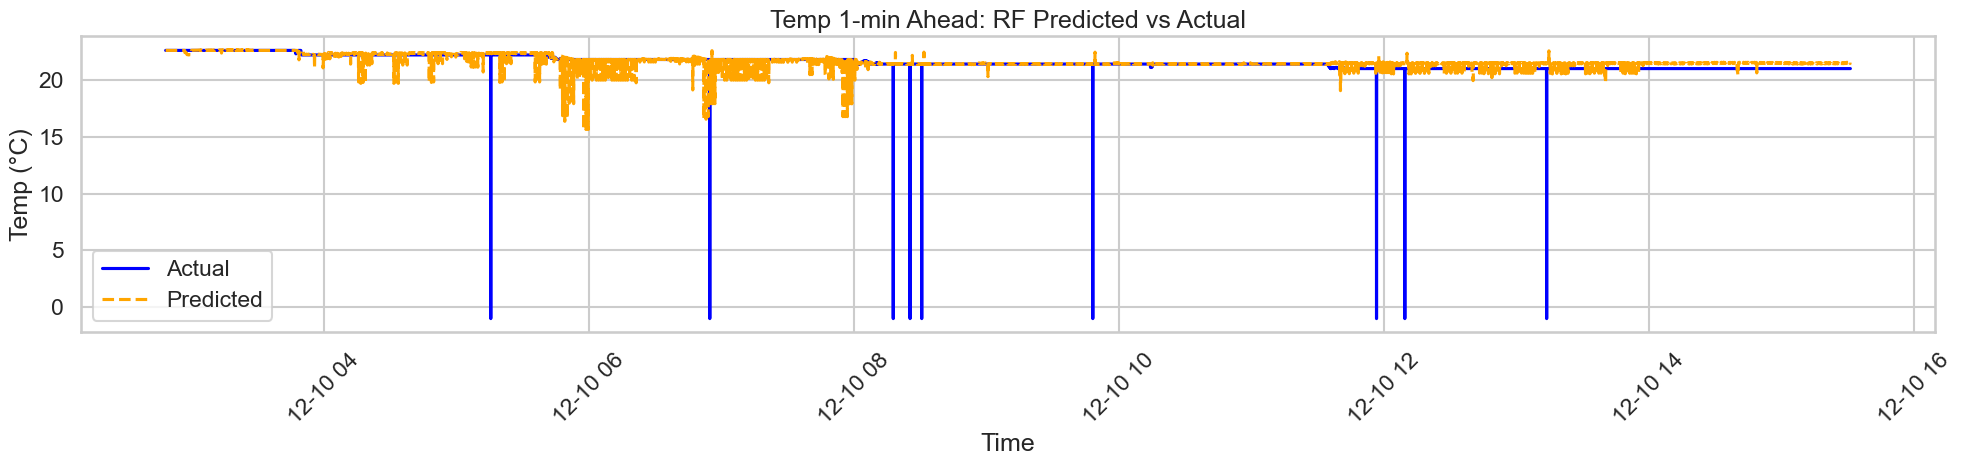

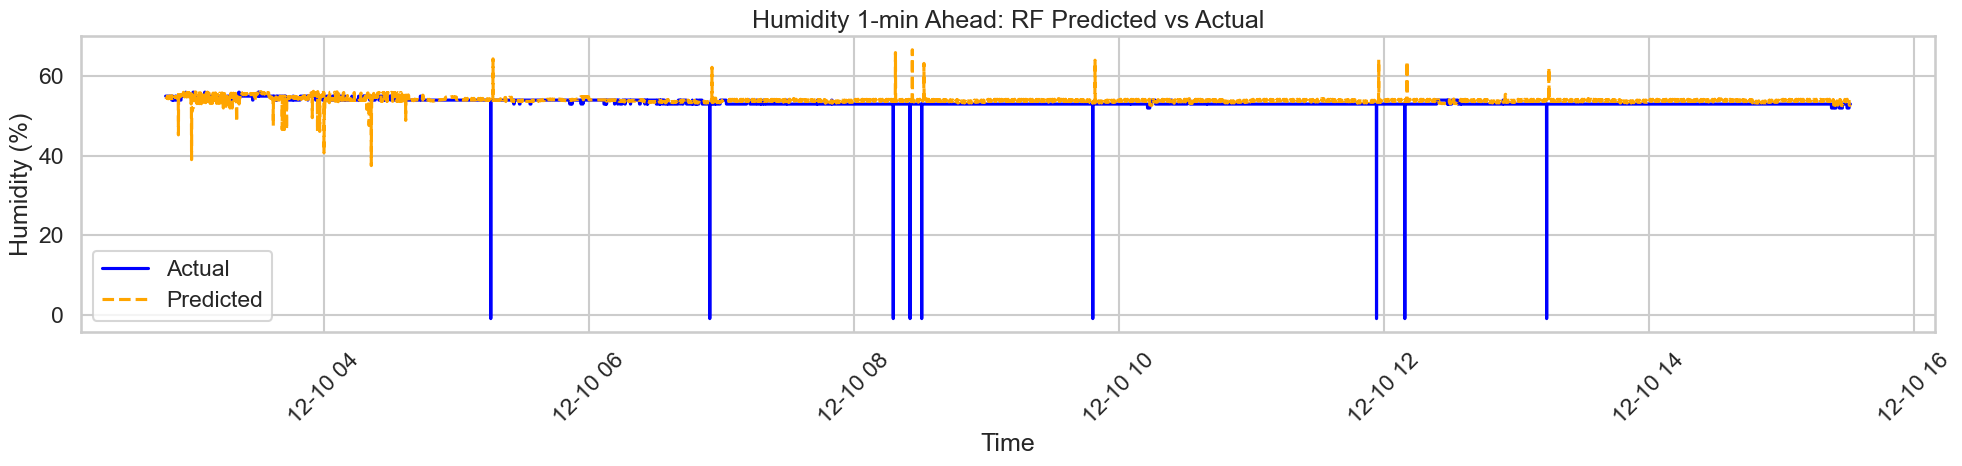

In [20]:
# Combine predictions and actuals
plot_df = pd.DataFrame({
    'Timestamp': data['Timestamp'].iloc[split_idx:split_idx+len(y_pred_rf)],
    'AQI_Actual': y_test['AQI_1min'].values,
    'AQI_Predicted': y_pred_rf[:, 0],
    'Temp_Actual': y_test['Temp_1min'].values,
    'Temp_Predicted': y_pred_rf[:, 3],
    'Hum_Actual': y_test['Hum_1min'].values,
    'Hum_Predicted': y_pred_rf[:, 6]
})

sns.set_style("whitegrid")
sns.set_context("talk")

def plot_var_time(actual_col, pred_col, ylabel, title):
    plt.figure(figsize=(20,5))
    sns.lineplot(x='Timestamp', y=actual_col, data=plot_df, label='Actual', color='blue')
    sns.lineplot(x='Timestamp', y=pred_col, data=plot_df, label='Predicted', color='orange', linestyle='--')
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()

# AQI
plot_var_time('AQI_Actual', 'AQI_Predicted', 'AQI', 'AQI 1-min Ahead: RF Predicted vs Actual')

# Temp
plot_var_time('Temp_Actual', 'Temp_Predicted', 'Temp (°C)', 'Temp 1-min Ahead: RF Predicted vs Actual')

# Hum
plot_var_time('Hum_Actual', 'Hum_Predicted', 'Humidity (%)', 'Humidity 1-min Ahead: RF Predicted vs Actual')